# Sentiment Analysis - Study 1

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import json
import re
from transformers import pipeline
from tqdm import tqdm
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
tqdm.pandas()

## Reading & cleaning the LLM responses

In [3]:
df = pd.read_csv('./processed/complete_ageRisk.csv', index_col=0)

In [40]:
# Extracts the text from the whole Copilot response 
def extract_bing_text(text):
    text = text.replace("\'", "'").replace('"', "'")
    match = re.search(r"'text': '(.*?)(?=', 'author': 'bot')", text)
    if match:
        text_content = match.group(1).replace("\\n", "\n")
        return text_content
    else:
        print("No 'text' field found in the input string.")
        return text

# Extracts the text from the whole Bard response
def extract_bard_text(text):
    text = text.replace("\'", "'").replace('"', "'")
    match = re.search(r"'content': '(.*?)', 'conversation_id'", text)
    if match:
        text_content = match.group(1).replace("\\n", "\n")
        return text_content
    else:
        print("No 'content' field found in the input string.")
        return text

# Extracts the human readable text from a GenAI response
def clean_raw(row):
    if row['ai'] == 'ChatGPT':
        return row['raw']
    elif row['ai'] == 'Bing':
        return extract_bing_text(row['raw'])
    else:
        return extract_bard_text(row['raw'])

In [5]:
df['raw_clean'] = df.apply(clean_raw, axis=1)

## Feature engineering

In [ ]:
# Sets the classification results
def get_oneshot_classes(df, classes, col, prefix):
    for label in classes:
        df[f'{prefix}-{label}'] = df[col].apply(lambda x: x['scores'][x['labels'].index(label)])
    return df

### Presence of a disclaimer

In [ ]:
zero_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
candidates_disclaimer = ['disclaimer', 'no disclaimer']

df_disclaimer = df.copy()
df_disclaimer['disclaimer_raw'] = df_disclaimer['raw_clean'].progress_apply(lambda res: zero_classifier(res, candidates_disclaimer))

In [ ]:
df_disclaimer = get_oneshot_classes(df_disclaimer, candidates_disclaimer, 'disclaimer_raw', 'disclaim')
df = df_disclaimer

### Presence of explanations

In [ ]:
candidates_explanations = ['explanations', 'no explanations']

df_explanations = df.copy()
df_explanations['explanations_raw'] = df_explanations['raw_clean'].progress_apply(lambda res: zero_classifier(res, candidates_explanations))

In [ ]:
df_explanations = get_oneshot_classes(df_explanations, candidates_explanations, 'explanations_raw', 'explain')
df = df_explanations

### Assertiveness

In [ ]:
candidates_assertive = ['assertive', 'non-assertive']

df_assertive = df.copy()
df_assertive['assertiveness_raw'] = df_assertive['raw_clean'].progress_apply(lambda res: zero_classifier(res, candidates_assertive))

In [ ]:
df_assertive = get_oneshot_classes(df_assertive, candidates_assertive, 'assertiveness_raw', 'assertive')
df=df_assertive

In [ ]:
df.to_csv('./processed/sentiment_features.csv')

## Analysis

In [3]:
df = pd.read_csv('./processed/sentiment_features.csv', index_col=0)
df.columns = df.columns.str.replace('-', '_').str.replace(' ', '_')
df['ai'] = df['ai'].replace({'Bing': 'Copilot','Bard': 'Gemini'})
df['risk_taking'] = df['risk_taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})

In [4]:
label_dict = {'ai':'GenAI', 'age':'Age', 'risk_taking':'Risk Tendency'}
rename_dict = {
    'disclaim_disclaimer' : 'Disclaimer',
    'disclaim_no_disclaimer':'No Disclaimer',
    'assertive_assertive':'Assertiveness',
    'assertive_non_assertive':'Non-Assertiveness',
    'explain_explanations':'Rationality',
    'explain_no_explanations':'Non-Rationality',  
}   

# Calculates the mean of classification classes
def show_colmeans(df, starter):
    for column_name in df.columns:
        if column_name.startswith(starter):
            print(f'mean for column {rename_dict[column_name]}: {round(df[column_name].mean(), 4)} with length: {df[column_name].size}')

# Calculates an ANOVA for a feature and the defined groups and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

# Prints a mean plot for a characteristic
def show_errplot(raw, column, column_label, group1, group2=None):
    if group1 == 'risk_taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
        
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    
    grouped = raw.groupby(groups, observed=False)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)
    
    plt.clf()
    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
        
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 4), zorder=2, color=colors)
    ax.set_ylabel(rename_dict[column_label])
    x_label = 'Condition' if group1 == 'cond' else label_dict.get(group1, group1)
    ax.set_xlabel(x_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.grid(True, zorder=1)
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/sentiment/{group1}{group2_label}-{column_label}.png', bbox_inches='tight')

# Prints the statistics and plots for all classes of a classification task
def show_model_details(df, starter, group1, group2=None):
    for column_name in df.columns:
        if column_name.startswith(starter):            
            show_errplot(df, column_name, column_name, group1, group2)
            plt.show()

### Disclaimer

In [5]:
show_colmeans(df, 'disclaim_')

mean for column Disclaimer: 0.9264 with length: 270
mean for column No Disclaimer: 0.0736 with length: 270


            sum_sq     df          F        PR(>F)
label     0.231127    2.0  38.954958  1.430688e-15
Residual  0.792081  267.0        NaN           NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
ChatGPT Copilot   0.0007 0.9957 -0.0184  0.0199  False
ChatGPT  Gemini  -0.0617    0.0 -0.0808 -0.0426   True
Copilot  Gemini  -0.0624    0.0 -0.0816 -0.0433   True
------------------------------------------------------
means:
ai
ChatGPT    0.9467
Copilot    0.9474
Gemini     0.8850
Name: disclaim_disclaimer, dtype: float64
stds:
ai
ChatGPT    0.0525
Copilot    0.0418
Gemini     0.0663
Name: disclaim_disclaimer, dtype: float64
ai
ChatGPT    90
Copilot    90
Gemini     90
Name: disclaim_disclaimer, dtype: int64


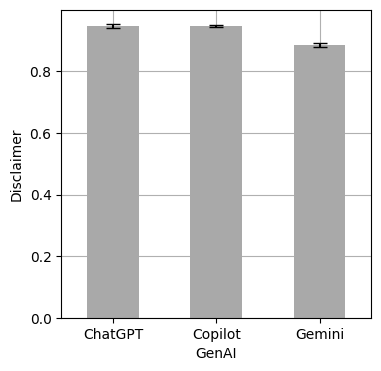

            sum_sq     df          F        PR(>F)
label     0.231127    2.0  38.954956  1.430691e-15
Residual  0.792081  267.0        NaN           NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot  -0.0007 0.9957 -0.0199 0.0184  False
ChatGPT  Gemini   0.0617    0.0  0.0426 0.0808   True
Copilot  Gemini   0.0624    0.0  0.0433 0.0816   True
-----------------------------------------------------
means:
ai
ChatGPT    0.0533
Copilot    0.0526
Gemini     0.1150
Name: disclaim_no_disclaimer, dtype: float64
stds:
ai
ChatGPT    0.0525
Copilot    0.0418
Gemini     0.0663
Name: disclaim_no_disclaimer, dtype: float64
ai
ChatGPT    90
Copilot    90
Gemini     90
Name: disclaim_no_disclaimer, dtype: int64


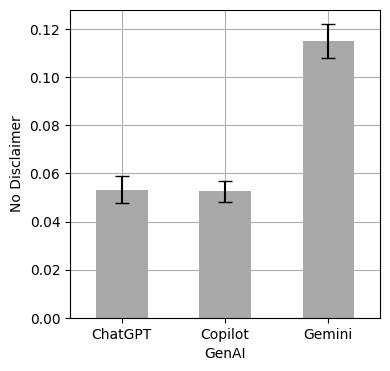

In [27]:
show_model_details(df, 'disclaim_', 'ai')

            sum_sq     df         F    PR(>F)
label     0.000084    1.0  0.022007  0.882181
Residual  1.023124  268.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0065 0.7628 -0.0282 0.0153  False
    15     50  -0.0019 0.9769 -0.0236 0.0198  False
    30     50   0.0046 0.8734 -0.0172 0.0263  False
---------------------------------------------------
means:
age
15    0.9292
30    0.9227
50    0.9273
Name: disclaim_disclaimer, dtype: float64
stds:
age
15    0.0591
30    0.0600
50    0.0661
Name: disclaim_disclaimer, dtype: float64
age
15    90
30    90
50    90
Name: disclaim_disclaimer, dtype: int64


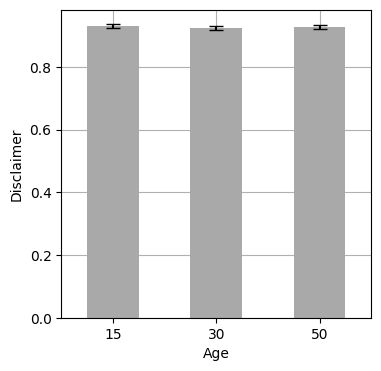

            sum_sq     df         F   PR(>F)
label     0.000084    1.0  0.022007  0.88218
Residual  1.023124  268.0       NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0065 0.7628 -0.0153 0.0282  False
    15     50   0.0019 0.9769 -0.0198 0.0236  False
    30     50  -0.0046 0.8734 -0.0263 0.0172  False
---------------------------------------------------
means:
age
15    0.0708
30    0.0773
50    0.0727
Name: disclaim_no_disclaimer, dtype: float64
stds:
age
15    0.0591
30    0.0600
50    0.0661
Name: disclaim_no_disclaimer, dtype: float64
age
15    90
30    90
50    90
Name: disclaim_no_disclaimer, dtype: int64


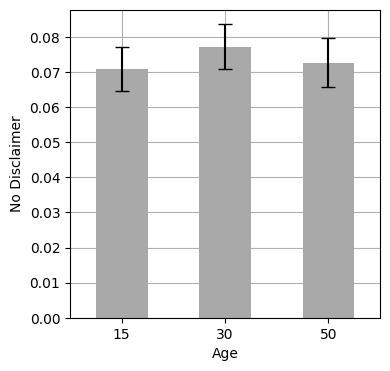

In [28]:
show_model_details(df, 'disclaim_', 'age')

            sum_sq     df          F    PR(>F)
label     0.089805    2.0  12.844305  0.000005
Residual  0.933404  267.0        NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -0.0425    0.0 -0.0633 -0.0218   True
  high medium  -0.0095 0.5308 -0.0302  0.0113  False
   low medium   0.0331 0.0006  0.0123  0.0538   True
----------------------------------------------------
means:
risk_taking
low       0.9012
medium    0.9343
high      0.9437
Name: disclaim_disclaimer, dtype: float64
stds:
risk_taking
low       0.0680
medium    0.0627
high      0.0439
Name: disclaim_disclaimer, dtype: float64
risk_taking
low       90
medium    90
high      90
Name: disclaim_disclaimer, dtype: int64


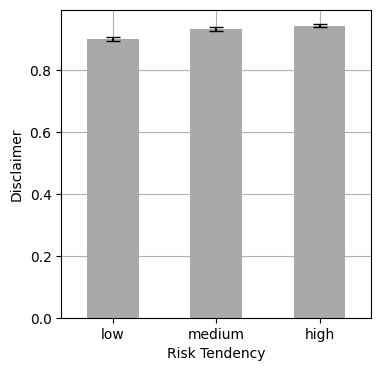

            sum_sq     df          F    PR(>F)
label     0.089805    2.0  12.844302  0.000005
Residual  0.933404  267.0        NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low   0.0425    0.0  0.0218  0.0633   True
  high medium   0.0095 0.5308 -0.0113  0.0302  False
   low medium  -0.0331 0.0006 -0.0538 -0.0123   True
----------------------------------------------------
means:
risk_taking
low       0.0988
medium    0.0657
high      0.0563
Name: disclaim_no_disclaimer, dtype: float64
stds:
risk_taking
low       0.0680
medium    0.0627
high      0.0439
Name: disclaim_no_disclaimer, dtype: float64
risk_taking
low       90
medium    90
high      90
Name: disclaim_no_disclaimer, dtype: int64


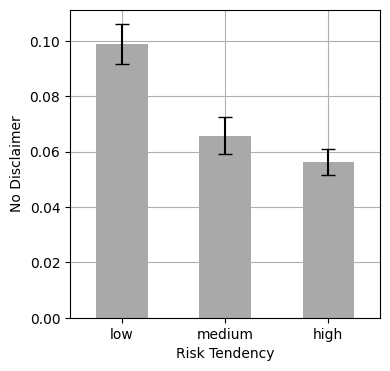

In [29]:
show_model_details(df, 'disclaim_', 'risk_taking')

            sum_sq     df          F        PR(>F)
label     0.333145    8.0  15.750536  6.634854e-19
Residual  0.690063  261.0        NaN           NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)  -0.0286  0.438 -0.0701  0.0129  False
  (ChatGPT, high) (ChatGPT, medium)  -0.0079 0.9996 -0.0494  0.0337  False
  (ChatGPT, high)   (Copilot, high)   0.0005    1.0 -0.0411   0.042  False
  (ChatGPT, high)    (Copilot, low)  -0.0402 0.0668 -0.0817  0.0014  False
  (ChatGPT, high) (Copilot, medium)   0.0054    1.0 -0.0361  0.0469  False
  (ChatGPT, high)    (Gemini, high)  -0.0459 0.0181 -0.0874 -0.0044   True
  (ChatGPT, high)     (Gemini, low)  -0.1043    0.0 -0.1458 -0.0628   True
  (ChatGPT, high)  (Gemini, medium)  -0.0714    0.0 -0.1129 -0.0299   True
   (ChatGPT, low) (Cha

<Figure size 640x480 with 0 Axes>

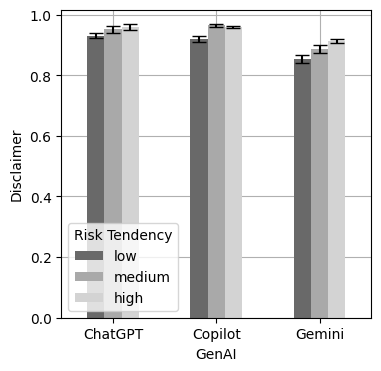

            sum_sq     df          F        PR(>F)
label     0.333145    8.0  15.750536  6.634866e-19
Residual  0.690063  261.0        NaN           NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)   0.0286  0.438 -0.0129 0.0701  False
  (ChatGPT, high) (ChatGPT, medium)   0.0079 0.9996 -0.0337 0.0494  False
  (ChatGPT, high)   (Copilot, high)  -0.0005    1.0  -0.042 0.0411  False
  (ChatGPT, high)    (Copilot, low)   0.0402 0.0668 -0.0014 0.0817  False
  (ChatGPT, high) (Copilot, medium)  -0.0054    1.0 -0.0469 0.0361  False
  (ChatGPT, high)    (Gemini, high)   0.0459 0.0181  0.0044 0.0874   True
  (ChatGPT, high)     (Gemini, low)   0.1043    0.0  0.0628 0.1458   True
  (ChatGPT, high)  (Gemini, medium)   0.0714    0.0  0.0299 0.1129   True
   (ChatGPT, low) (ChatGPT, mediu

<Figure size 640x480 with 0 Axes>

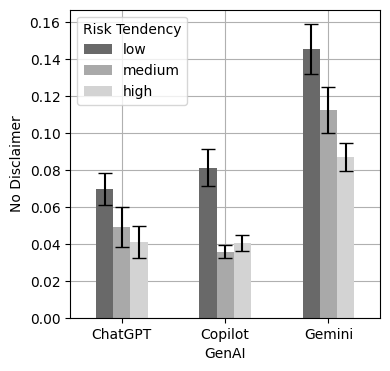

In [30]:
show_model_details(df, 'disclaim_', 'ai', 'risk_taking')

### Explanations

In [31]:
show_colmeans(df, 'explain_')

mean for column Rationality: 0.9623 with length: 270
mean for column Non-Rationality: 0.0377 with length: 270


            sum_sq     df          F    PR(>F)
label     0.009226    2.0  12.252014  0.000008
Residual  0.100531  267.0        NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot   0.0142    0.0  0.0074 0.0211   True
ChatGPT  Gemini   0.0085 0.0105  0.0016 0.0153   True
Copilot  Gemini  -0.0058 0.1147 -0.0126  0.001  False
-----------------------------------------------------
means:
ai
ChatGPT    0.9548
Copilot    0.9690
Gemini     0.9632
Name: explain_explanations, dtype: float64
stds:
ai
ChatGPT    0.0246
Copilot    0.0161
Gemini     0.0162
Name: explain_explanations, dtype: float64
ai
ChatGPT    90
Copilot    90
Gemini     90
Name: explain_explanations, dtype: int64


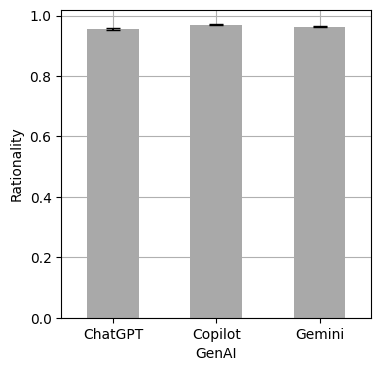

            sum_sq     df          F    PR(>F)
label     0.009226    2.0  12.252021  0.000008
Residual  0.100531  267.0        NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
ChatGPT Copilot  -0.0142    0.0 -0.0211 -0.0074   True
ChatGPT  Gemini  -0.0085 0.0105 -0.0153 -0.0016   True
Copilot  Gemini   0.0058 0.1147  -0.001  0.0126  False
------------------------------------------------------
means:
ai
ChatGPT    0.0452
Copilot    0.0310
Gemini     0.0368
Name: explain_no_explanations, dtype: float64
stds:
ai
ChatGPT    0.0246
Copilot    0.0161
Gemini     0.0162
Name: explain_no_explanations, dtype: float64
ai
ChatGPT    90
Copilot    90
Gemini     90
Name: explain_no_explanations, dtype: int64


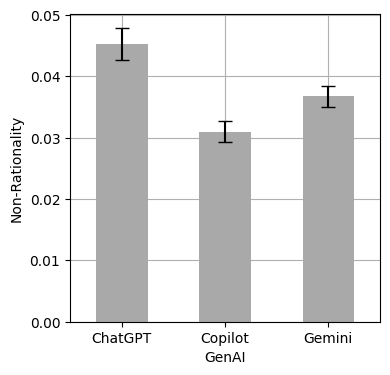

In [32]:
show_model_details(df, 'explain_', 'ai')

            sum_sq     df         F    PR(>F)
label     0.000681    1.0  1.673297  0.196931
Residual  0.109076  268.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0022 0.7344 -0.0048 0.0093  False
    15     50  -0.0035 0.4701 -0.0106 0.0036  False
    30     50  -0.0058 0.1343 -0.0128 0.0013  False
---------------------------------------------------
means:
age
15    0.9628
30    0.9650
50    0.9592
Name: explain_explanations, dtype: float64
stds:
age
15    0.0176
30    0.0156
50    0.0257
Name: explain_explanations, dtype: float64
age
15    90
30    90
50    90
Name: explain_explanations, dtype: int64


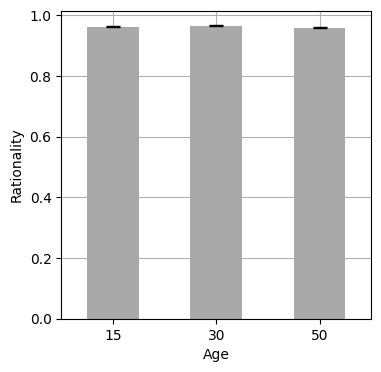

            sum_sq     df         F    PR(>F)
label     0.000681    1.0  1.673301  0.196931
Residual  0.109076  268.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0022 0.7344 -0.0093 0.0048  False
    15     50   0.0035 0.4701 -0.0036 0.0106  False
    30     50   0.0058 0.1343 -0.0013 0.0128  False
---------------------------------------------------
means:
age
15    0.0372
30    0.0350
50    0.0408
Name: explain_no_explanations, dtype: float64
stds:
age
15    0.0176
30    0.0156
50    0.0257
Name: explain_no_explanations, dtype: float64
age
15    90
30    90
50    90
Name: explain_no_explanations, dtype: int64


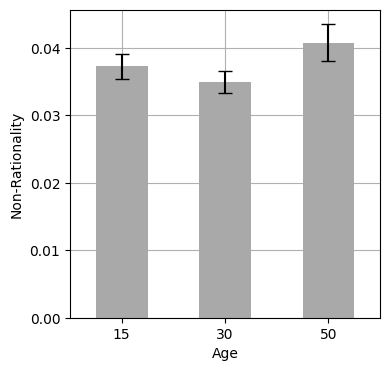

In [33]:
show_model_details(df, 'explain_', 'age')

            sum_sq     df         F    PR(>F)
label     0.000617    2.0  0.755272  0.470884
Residual  0.109140  267.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   0.0016 0.8513 -0.0055 0.0087  False
  high medium   0.0037 0.4388 -0.0034 0.0108  False
   low medium   0.0021 0.7721  -0.005 0.0092  False
---------------------------------------------------
means:
risk_taking
low       0.9622
medium    0.9643
high      0.9606
Name: explain_explanations, dtype: float64
stds:
risk_taking
low       0.0190
medium    0.0213
high      0.0203
Name: explain_explanations, dtype: float64
risk_taking
low       90
medium    90
high      90
Name: explain_explanations, dtype: int64


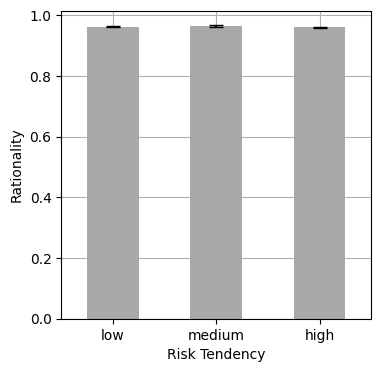

            sum_sq     df         F    PR(>F)
label     0.000617    2.0  0.755271  0.470884
Residual  0.109140  267.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low  -0.0016 0.8513 -0.0087 0.0055  False
  high medium  -0.0037 0.4388 -0.0108 0.0034  False
   low medium  -0.0021 0.7721 -0.0092  0.005  False
---------------------------------------------------
means:
risk_taking
low       0.0378
medium    0.0357
high      0.0394
Name: explain_no_explanations, dtype: float64
stds:
risk_taking
low       0.0190
medium    0.0213
high      0.0203
Name: explain_no_explanations, dtype: float64
risk_taking
low       90
medium    90
high      90
Name: explain_no_explanations, dtype: int64


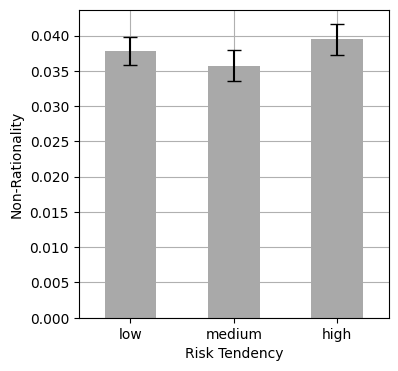

In [34]:
show_model_details(df, 'explain_', 'risk_taking')

### Assertiveness

In [35]:
show_colmeans(df , 'assertive_')

mean for column Assertiveness: 0.5924 with length: 270
mean for column Non-Assertiveness: 0.4076 with length: 270


            sum_sq     df         F    PR(>F)
label     0.064542    2.0  3.019203  0.050511
Residual  2.853844  267.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
ChatGPT Copilot  -0.0377 0.0399  -0.074 -0.0014   True
ChatGPT  Gemini  -0.0156 0.5679  -0.052  0.0207  False
Copilot  Gemini    0.022 0.3268 -0.0143  0.0584  False
------------------------------------------------------
means:
ai
ChatGPT    0.6102
Copilot    0.5725
Gemini     0.5945
Name: assertive_assertive, dtype: float64
stds:
ai
ChatGPT    0.1067
Copilot    0.1030
Gemini     0.1004
Name: assertive_assertive, dtype: float64
ai
ChatGPT    90
Copilot    90
Gemini     90
Name: assertive_assertive, dtype: int64


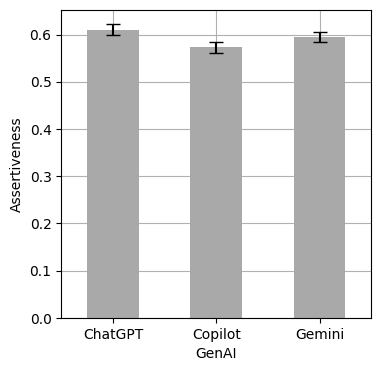

            sum_sq     df         F    PR(>F)
label     0.064542    2.0  3.019203  0.050511
Residual  2.853844  267.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot   0.0377 0.0399  0.0014  0.074   True
ChatGPT  Gemini   0.0156 0.5679 -0.0207  0.052  False
Copilot  Gemini   -0.022 0.3268 -0.0584 0.0143  False
-----------------------------------------------------
means:
ai
ChatGPT    0.3898
Copilot    0.4275
Gemini     0.4055
Name: assertive_non_assertive, dtype: float64
stds:
ai
ChatGPT    0.1067
Copilot    0.1030
Gemini     0.1004
Name: assertive_non_assertive, dtype: float64
ai
ChatGPT    90
Copilot    90
Gemini     90
Name: assertive_non_assertive, dtype: int64


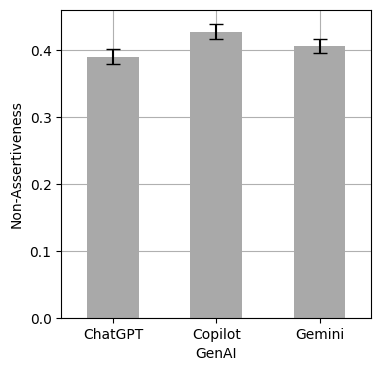

In [36]:
show_model_details(df, 'assertive_', 'ai')

            sum_sq     df         F    PR(>F)
label     0.013097    1.0  1.208144  0.272686
Residual  2.905289  268.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.0095 0.8139 -0.0462 0.0271  False
    15     50  -0.0172 0.5109 -0.0539 0.0194  False
    30     50  -0.0077 0.8739 -0.0443  0.029  False
---------------------------------------------------
means:
age
15    0.6013
30    0.5918
50    0.5841
Name: assertive_assertive, dtype: float64
stds:
age
15    0.1015
30    0.1031
50    0.1081
Name: assertive_assertive, dtype: float64
age
15    90
30    90
50    90
Name: assertive_assertive, dtype: int64


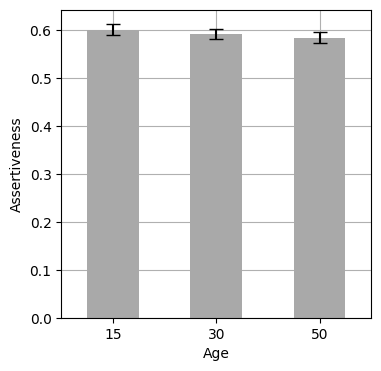

            sum_sq     df         F    PR(>F)
label     0.013097    1.0  1.208142  0.272687
Residual  2.905289  268.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0095 0.8139 -0.0271 0.0462  False
    15     50   0.0172 0.5109 -0.0194 0.0539  False
    30     50   0.0077 0.8739  -0.029 0.0443  False
---------------------------------------------------
means:
age
15    0.3987
30    0.4082
50    0.4159
Name: assertive_non_assertive, dtype: float64
stds:
age
15    0.1015
30    0.1031
50    0.1081
Name: assertive_non_assertive, dtype: float64
age
15    90
30    90
50    90
Name: assertive_non_assertive, dtype: int64


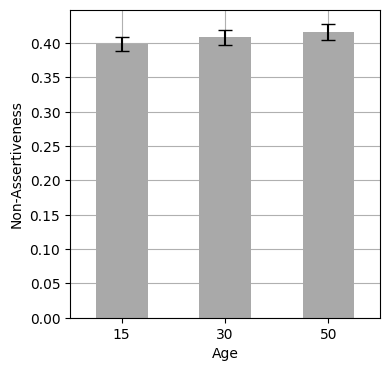

In [37]:
show_model_details(df, 'assertive_', 'age')

            sum_sq     df          F        PR(>F)
label     0.378660    2.0  19.904181  8.759580e-09
Residual  2.539726  267.0        NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -0.0821    0.0 -0.1163 -0.0478   True
  high medium  -0.0765    0.0 -0.1108 -0.0422   True
   low medium   0.0056 0.9225 -0.0287  0.0398  False
----------------------------------------------------
means:
risk_taking
low       0.5632
medium    0.5688
high      0.6453
Name: assertive_assertive, dtype: float64
stds:
risk_taking
low       0.1110
medium    0.0988
high      0.0804
Name: assertive_assertive, dtype: float64
risk_taking
low       90
medium    90
high      90
Name: assertive_assertive, dtype: int64


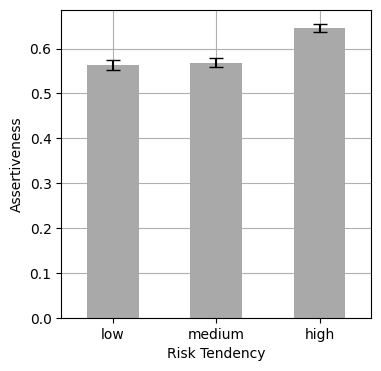

            sum_sq     df          F        PR(>F)
label     0.378660    2.0  19.904182  8.759569e-09
Residual  2.539726  267.0        NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  high    low   0.0821    0.0  0.0478 0.1163   True
  high medium   0.0765    0.0  0.0422 0.1108   True
   low medium  -0.0056 0.9225 -0.0398 0.0287  False
---------------------------------------------------
means:
risk_taking
low       0.4368
medium    0.4312
high      0.3547
Name: assertive_non_assertive, dtype: float64
stds:
risk_taking
low       0.1110
medium    0.0988
high      0.0804
Name: assertive_non_assertive, dtype: float64
risk_taking
low       90
medium    90
high      90
Name: assertive_non_assertive, dtype: int64


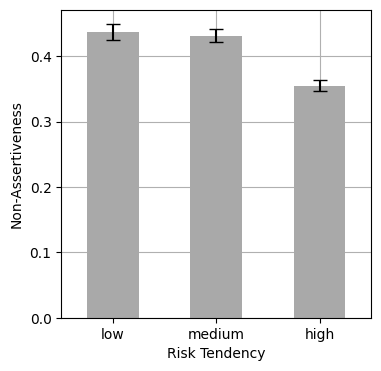

In [38]:
show_model_details(df, 'assertive_', 'risk_taking')

            sum_sq     df          F        PR(>F)
label     0.797348    8.0  12.264512  6.886942e-15
Residual  2.121038  261.0        NaN           NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)   0.0084    1.0 -0.0644  0.0812  False
  (ChatGPT, high) (ChatGPT, medium)  -0.0737 0.0446 -0.1465 -0.0009   True
  (ChatGPT, high)   (Copilot, high)   0.0305 0.9272 -0.0423  0.1033  False
  (ChatGPT, high)    (Copilot, low)  -0.1043 0.0004 -0.1771 -0.0315   True
  (ChatGPT, high) (Copilot, medium)  -0.1046 0.0004 -0.1774 -0.0318   True
  (ChatGPT, high)    (Gemini, high)   0.0094    1.0 -0.0634  0.0822  False
  (ChatGPT, high)     (Gemini, low)  -0.1104 0.0001 -0.1832 -0.0376   True
  (ChatGPT, high)  (Gemini, medium)  -0.0113 0.9999 -0.0841  0.0615  False
   (ChatGPT, low) (Cha

<Figure size 640x480 with 0 Axes>

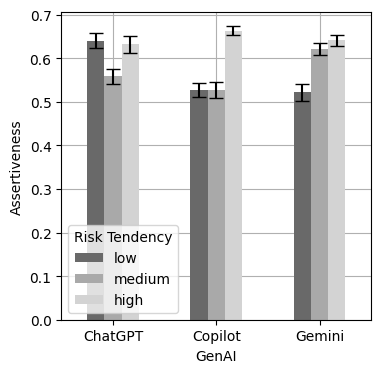

            sum_sq     df          F        PR(>F)
label     0.797348    8.0  12.264514  6.886921e-15
Residual  2.121038  261.0        NaN           NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)  -0.0084    1.0 -0.0812  0.0644  False
  (ChatGPT, high) (ChatGPT, medium)   0.0737 0.0446  0.0009  0.1465   True
  (ChatGPT, high)   (Copilot, high)  -0.0305 0.9272 -0.1033  0.0423  False
  (ChatGPT, high)    (Copilot, low)   0.1043 0.0004  0.0315  0.1771   True
  (ChatGPT, high) (Copilot, medium)   0.1046 0.0004  0.0318  0.1774   True
  (ChatGPT, high)    (Gemini, high)  -0.0094    1.0 -0.0822  0.0634  False
  (ChatGPT, high)     (Gemini, low)   0.1104 0.0001  0.0376  0.1832   True
  (ChatGPT, high)  (Gemini, medium)   0.0113 0.9999 -0.0615  0.0841  False
   (ChatGPT, low) (Cha

<Figure size 640x480 with 0 Axes>

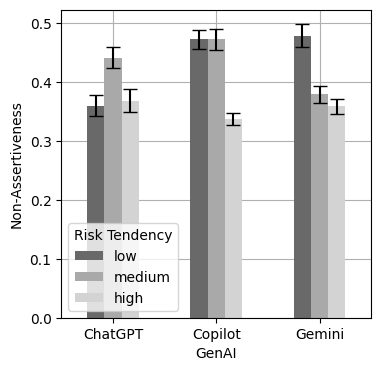

In [39]:
show_model_details(df, 'assertive_', 'ai', 'risk_taking')